# TP - CNN Transfert learning

Example de l'utilisation d'un modèle Deep Learning pré-entraîné (VGG-16) pour apprentissage de la reconnaissance de chats et de chiens dans des images.

## Récupération des images

Avant d'exécuter ce notebook, performer les actions suivantes:  

- Aller sur Kaggle page "https://www.kaggle.com/datasets/tongpython/cat-and-dog"  
- Cliquer sur bouton "download" en haut à doite et télécharger le fichier zip  
- Ouvrir le fichier zip en local  
- Créer un sous dossiers ./data/raw  
- Copier les images du répertoire training_set contenant /cats et /dogs vers ./data/raw
- idem pour le répertoire test_set
- Vérifier que les répertoires raw/test_set et raw/training_set sont maintenant disponibles  

## Récupération des images

In [27]:
# 1. Créer dossiers
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/train/cats', exist_ok=True)
os.makedirs('data/train/dogs', exist_ok=True)
os.makedirs('data/val/cats', exist_ok=True)
os.makedirs('data/val/dogs', exist_ok=True)
os.makedirs('data/test/cats', exist_ok=True)
os.makedirs('data/test/dogs', exist_ok=True)

# 4. Split 80/20 et organiser
print("🔄 Split 80% train / 20% val...")
train_dir = defaultdict(list)
val_dir = defaultdict(list)

# Collecter fichiers
cat_images = Path('data/raw/training_set/cats')
cat_files = list(cat_images.glob('cat.*.jpg'))
dog_images = Path('data/raw/training_set/dogs')
dog_files = list(dog_images.glob('dog.*.jpg'))

random.shuffle(cat_files)
random.shuffle(dog_files)

# Split chats
split_idx = int(0.8 * len(cat_files))
train_dir['cats'] = cat_files[:split_idx]
val_dir['cats'] = cat_files[split_idx:]

# Split chiens
split_idx = int(0.8 * len(dog_files))
train_dir['dogs'] = dog_files[:split_idx]
val_dir['dogs'] = dog_files[split_idx:]

# 5. Déplacer fichiers
for classe, files in train_dir.items():
    for f in files:
        shutil.copy(str(f), f'data/train/{classe}/')
for classe, files in val_dir.items():
    for f in files:
        shutil.copy(str(f), f'data/val/{classe}/')

# Chercher et copier TOUS les fichiers .jpg récursivement
source_dir = Path('data/raw/test_set')
cats_copied = 0
dogs_copied = 0

print("🐱🐶 Copie avec sous-dossiers cats/dogs...")

for file_path in source_dir.rglob('*.jpg'):
    filename = file_path.name.lower()
    
    if 'cat' in filename:
        shutil.copy2(file_path, 'data/test/cats/')
        cats_copied += 1
    elif 'dog' in filename:
        shutil.copy2(file_path, 'data/test/dogs/')
        dogs_copied += 1

print(f"✅ data/test/cats/  : {cats_copied} images")
print(f"   data/test/dogs/ : {dogs_copied} images")

# Stats
print("✅ Structure créée :")
print(f"  Train - Chat:  {len(os.listdir('data/train/cats')):>4}")
print(f"         Chien: {len(os.listdir('data/train/dogs')):>4}")
print(f"  Val  - Chat:  {len(os.listdir('data/val/cats')):>4}")
print(f"         Chien: {len(os.listdir('data/val/dogs')):>4}")
print(f"  Test  - Chat:  {len(os.listdir('data/test/cats')):>4}")
print(f"          Chien: {len(os.listdir('data/test/dogs')):>4}")

🔄 Split 80% train / 20% val...
🐱🐶 Copie avec sous-dossiers cats/dogs...
✅ data/test/cats/  : 1011 images
   data/test/dogs/ : 1012 images
✅ Structure créée :
  Train - Chat:  4000
         Chien: 4005
  Val  - Chat:  3282
         Chien: 3183
  Test  - Chat:  1011
          Chien: 1012


## Import des librairies

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

## Chargement du modèle VGG16 pré-entraîné

In [29]:
# VGG16 sans tête finale (include_top=False)
base_model = VGG16(weights='imagenet', 
                   include_top=False, 
                   input_shape=(224, 224, 3))

# Gèle les couches pour transfert learning
base_model.trainable = False

base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

## Ajout d'un classifieur

In [30]:
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),  # évite le surapprentissage
    layers.Dense(2, activation='softmax')  # 2 classes: chat/chien
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,986 (80.64 MB)

 Trainable params: 6,423,298 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## 5. Data Augmentation et Générateurs

In [37]:
# Dossiers (créez data/train/chat/, data/train/chien/, data/val/...)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Charge images depuis dossiers
print("Loading images used to train the model...")
train_generator = train_datagen.flow_from_directory(
    'data/train/',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)
print()
print("Loading images used to evaluate the model...")
val_generator = val_datagen.flow_from_directory(
    'data/val/',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)


Loading images used to train the model...
Found 8005 images belonging to 2 classes.

Loading images used to evaluate the model...
Found 6465 images belonging to 2 classes.


# 6. Compiler et Entraîner

In [40]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    steps_per_epoch=10,  # Ajustez selon vos données
    epochs=5,
    validation_data=val_generator,
    validation_steps=5
)


Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 45s 5s/step - accuracy: 0.7937 - loss: 0.4504 - val_accuracy: 0.8813 - val_loss: 0.2743
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 43s 5s/step - accuracy: 0.7563 - loss: 0.4847 - val_accuracy: 0.8750 - val_loss: 0.3560
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 44s 5s/step - accuracy: 0.8125 - loss: 0.4194 - val_accuracy: 0.8625 - val_loss: 0.3073
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 43s 5s/step - accuracy: 0.8469 - loss: 0.3527 - val_accuracy: 0.9125 - val_loss: 0.2507
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 43s 5s/step - accuracy: 0.8625 - loss: 0.3326 - val_accuracy: 0.9000 - val_loss: 0.2493


## Fine-tuning

In [51]:
# Optionnel : fine-tune dernières couches VGG
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 2  # Dernières couches

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(optimizer=keras.optimizers.Adam(1e-5/10),  # LR plus petit
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_fine = model.fit(train_generator, epochs=5,
                         validation_data=val_generator)

Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1397s 6s/step - accuracy: 0.8696 - loss: 0.3008 - val_accuracy: 0.9219 - val_loss: 0.1973
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1394s 6s/step - accuracy: 0.8766 - loss: 0.2924 - val_accuracy: 0.9222 - val_loss: 0.1955
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1468s 6s/step - accuracy: 0.8796 - loss: 0.2858 - val_accuracy: 0.9245 - val_loss: 0.1906
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1454s 6s/step - accuracy: 0.8832 - loss: 0.2796 - val_accuracy: 0.9267 - val_loss: 0.1849
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1412s 6s/step - accuracy: 0.8828 - loss: 0.2792 - val_accuracy: 0.9287 - val_loss: 0.1817


## 8. Évaluation et Visualisation

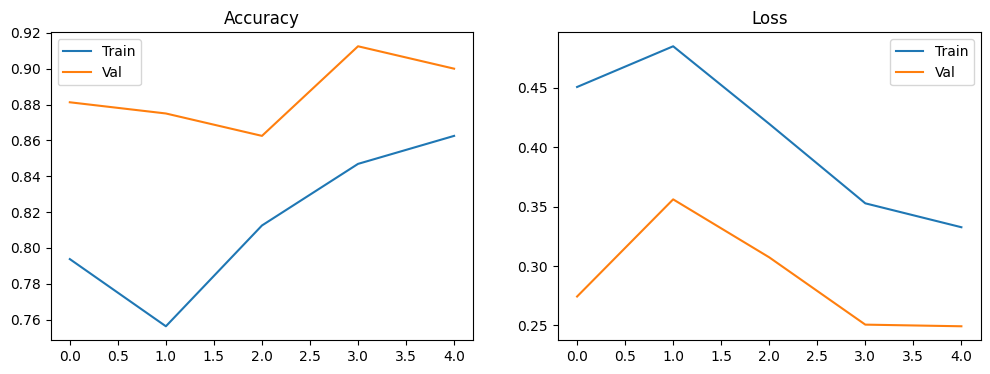

In [53]:
# Histoire précision/perte
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.show()

## 9. Test Nouvelle Image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Prédiction: cats (88.7%)


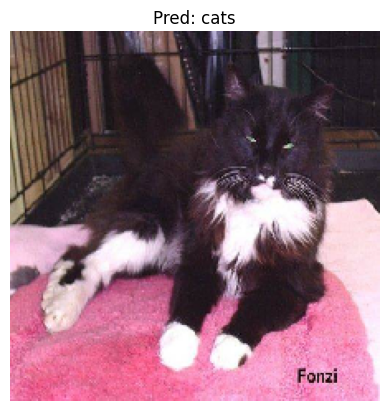

In [56]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Chargez votre image (224x224)
img_path = 'data/test/cats/cat.4010.jpg'
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

pred = model.predict(img_array)
classes = list(train_generator.class_indices.keys())
pred_class = classes[np.argmax(pred)]

print(f"Prédiction: {pred_class} ({100*np.max(pred):.1f}%)")
plt.imshow(img)
plt.title(f"Pred: {pred_class}")
plt.axis('off')
plt.show()


In [57]:
model.save('vgg16_transfer_learning.h5')
print("✅ Modèle VGG16 fine-tuné sauvé !")


✅ Modèle VGG16 fine-tuné sauvé !
